### Hello Soft Clustering (GMM)

Recall from HW1 we did K-means clustering. Fitting a GMM on a set of points can be considered
as another method to do clustering but now with soft assignments. Consider the same set of
points we used in HW1.

In class, we showed that we could fit a GMM on 1-dimensional data by using Expectation
Maximization (EM). The algorithm for doing EM on N-dimensional GMM is very similar. The exact
algorithm is as follows:

Initialization: Initialize the mixture weights, $φ = mj$, where j is the mixture number,

means of each Gaussian μj

(now a vector of N dimensions), and covariance matrices of each

Gaussian, Σj
.
Expectation: Find the soft assignments for each data point wn,j where n corresponds to the
sample index.

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import copy
import os


<Axes: xlabel='x', ylabel='y'>

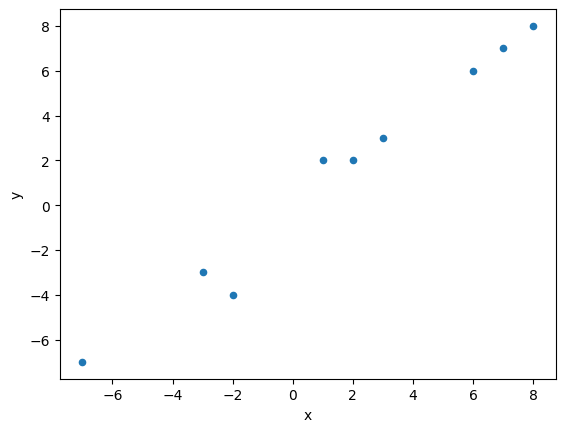

In [35]:
d={ 'x' : [1,3,2,8,6,7,-3,-2,-7],
    'y' : [2,3,2,8,6,7,-3,-4,-7],
    'group' : [None]*9 }


df = pd.DataFrame(d)

df.plot.scatter(x='x',y='y')

In [36]:
X = np.array([[1, 2], [3, 3], [2, 2], [8, 8], [6, 6], [7, 7], [-3, -3], [-2, -4], [-7, -7]])
n_samples, n_features = X.shape
k = 3

# Initialization
mu = np.array([[3.0, 3.0], [2.0, 2.0], [-3.0, -3.0]])
sigma = [np.eye(n_features) for _ in range(k)]
phi = np.array([1/3, 1/3, 1/3])

# Responsibilities (soft assignments) matrix
w = np.zeros((n_samples, k))

#### Part 1
Using 3 mixtures, initialize your Gaussian with means (3,3), (2,2), and (-3,-3), 
and standard Covariance, I, the identity matrix. Use equal mixture weights as the initial weights.
Repeat three iterations of EM. Write down wn,j
, mj
, μ⃑j
, Σj and plot the likelihood distributions (3
Gaussians) of each feature for each EM iteration. (You may do the calculations by hand or write
code to do so) (5 points)

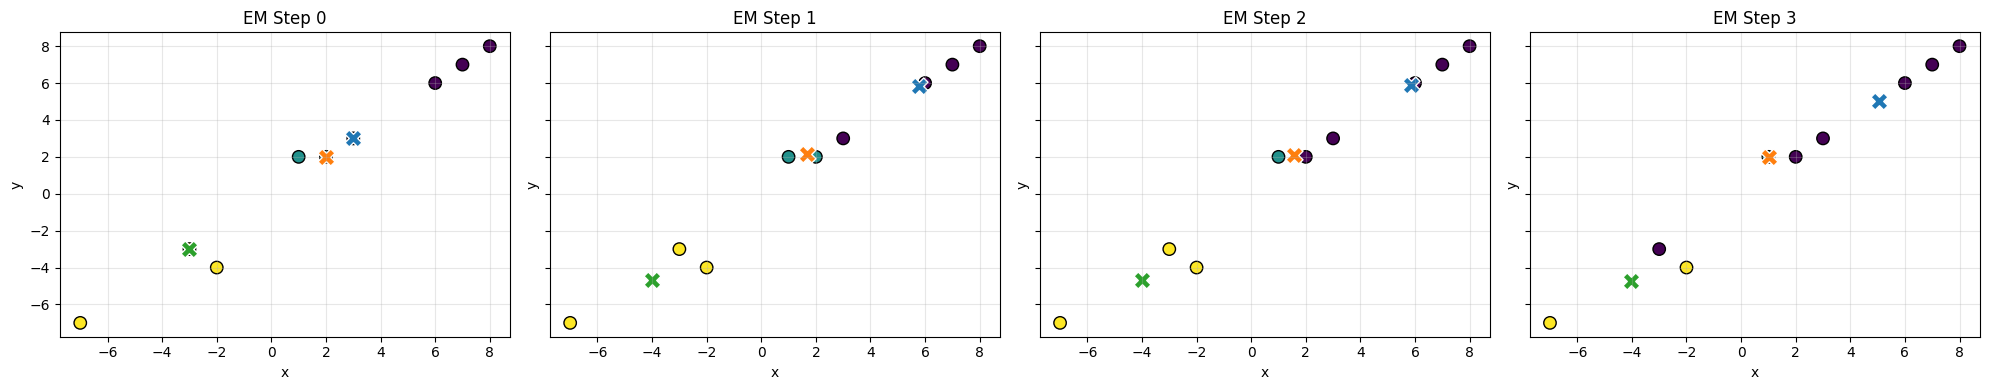

In [37]:
def mvn_pdf(x, mean, cov):
    n = len(mean)
    det = np.linalg.det(cov)
    inv = np.linalg.inv(cov)
    diff = x - mean
    exponent = -0.5 * (diff @ inv @ diff.T)
    return (1.0 / np.sqrt(((2 * np.pi) ** n) * det)) * np.exp(exponent)

def compute_responsibilities(X, mu, sigma, phi):
    n_samples = X.shape[0]
    k = len(phi)
    w = np.zeros((n_samples, k))
    for i in range(n_samples):
        for j in range(k):
            w[i, j] = phi[j] * mvn_pdf(X[i], mu[j], sigma[j])
        w[i, :] /= np.sum(w[i, :])
    return w

history = []
w = compute_responsibilities(X, mu, sigma, phi)
history.append((0, mu.copy(), phi.copy(), np.argmax(w, axis=1)))
# Calculate initial Log-Likelihood before any updates
initial_ll = sum(np.log(sum(phi[j] * mvn_pdf(x, mu[j], sigma[j]) for j in range(k))) for x in X)
log_likelihoods = []
log_likelihoods.append(initial_ll)

for step in range(1, 4):
    n_j = np.sum(w, axis=0)
    for j in range(k):
        phi[j] = n_j[j] / n_samples
        mu[j] = (w[:, j] @ X) / n_j[j]
        diff = X - mu[j]
        sigma[j] = (w[:, j] * diff.T @ diff) / n_j[j] + np.eye(n_features) * 1e-6
    w = compute_responsibilities(X, mu, sigma, phi)
    history.append((step, mu.copy(), phi.copy(), np.argmax(w, axis=1)))
    ll = sum(np.log(sum(phi[j] * mvn_pdf(x, mu[j], sigma[j]) for j in range(k))) for x in X)
    log_likelihoods.append(ll)

# Plot cluster assignments at each step
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharex=True, sharey=True)
for ax, (step, mu_step, phi_step, labels_step) in zip(axes, history):
    ax.scatter(X[:, 0], X[:, 1], c=labels_step, cmap='viridis', s=80, edgecolors='k')
    for j in range(k):
        ax.scatter(mu_step[j, 0], mu_step[j, 1], marker='X', s=150, c=f'C{j}', edgecolors='white')
    ax.set_title(f"EM Step {step}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.3)
labels = np.argmax(w, axis=1)
plt.tight_layout()
plt.show()

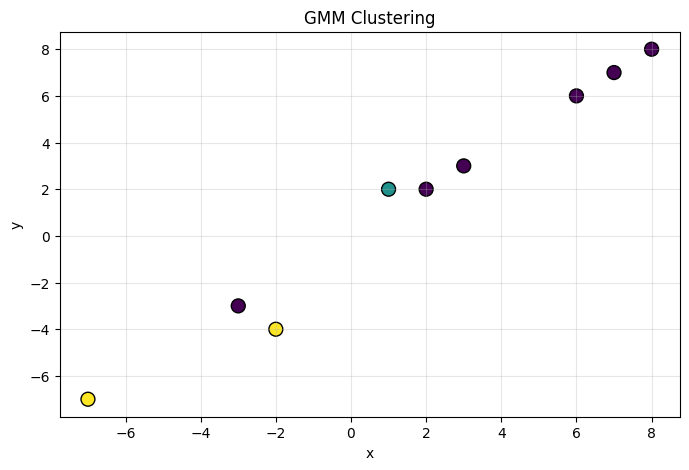

In [38]:
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=100, edgecolors='k')
plt.title("GMM Clustering")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.show()

#### Part 2 
Plot the log likelihood of the model given the data after each EM step. Does it goes up
every iteration just as we learned in class? (3 points)


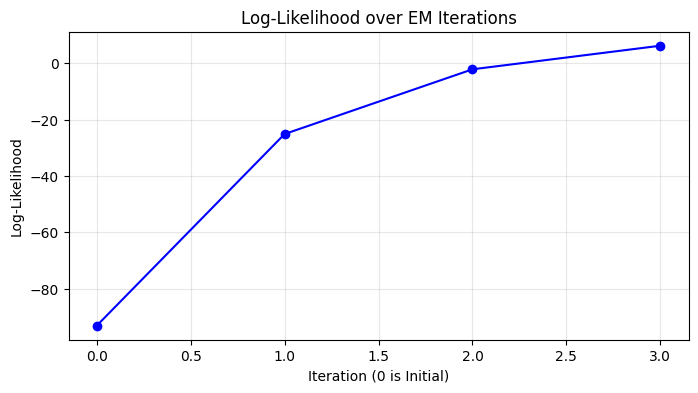

Log-Likelihoods: [np.float64(-93.17390123755949), np.float64(-25.152276555206537), np.float64(-2.1822488868411547), np.float64(6.186369895775084)]


In [39]:
plt.figure(figsize=(8, 4))
plt.plot(range(len(log_likelihoods)), log_likelihoods, marker='o', linestyle='-', color='b')
plt.title("Log-Likelihood over EM Iterations")
plt.xlabel("Iteration (0 is Initial)")
plt.ylabel("Log-Likelihood")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Log-Likelihoods: {log_likelihoods}")

#### Part 3
Using 2 mixtures, initialize your Gaussian with means (3,3), and (3,-3), and standard
Covariance, I, the identity matrix. Use equal mixture weights as the initial weights. Repeat three
iterations of EM. Write down wn,j
, mj
, μ⃑j
, Σj and plot the likelihood distributions (2 Gaussians) of

each feature for each EM iteration. (5 points)

In [40]:
X = np.array([[1, 2], [3, 3], [2, 2], [8, 8], [6, 6], [7, 7], [-3, -3], [-2, -4], [-7, -7]])
n_samples, n_features = X.shape
k_2 = 2

# Initialization
mu_2 = np.array([[3.0, 3.0], [-3.0, -3.0]])
sigma_2 = [np.eye(n_features) for _ in range(k_2)]
phi_2 = np.array([1/2, 1/2])

# Responsibilities (soft assignments) matrix
w_2 = np.zeros((n_samples, k_2))

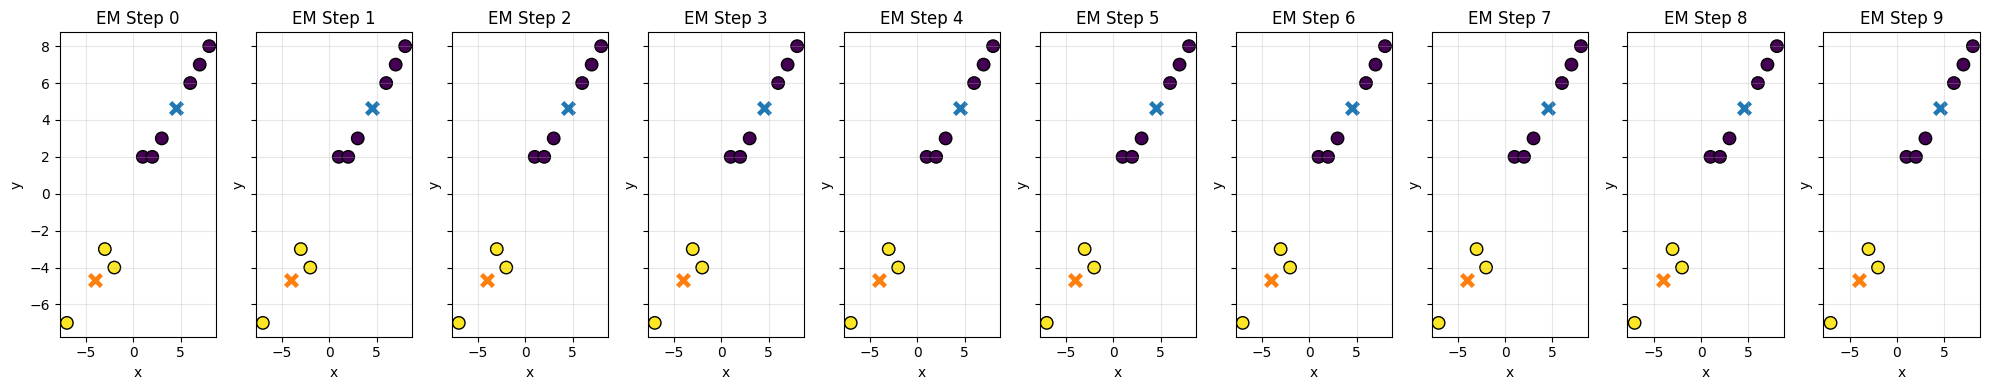

In [45]:
history = []
w_2 = compute_responsibilities(X, mu_2, sigma_2, phi_2)
history.append((0, mu_2.copy(), phi_2.copy(), np.argmax(w_2, axis=1)))
# Calculate initial Log-Likelihood before any updates
initial_ll_2 = sum(np.log(sum(phi_2[j] * mvn_pdf(x, mu_2[j], sigma_2[j]) for j in range(k_2))) for x in X)
log_likelihoods_2 = []
log_likelihoods_2.append(initial_ll_2)

for step in range(1, 10):
    n_j = np.sum(w_2, axis=0)
    for j in range(k_2):
        phi_2[j] = n_j[j] / n_samples
        mu_2[j] = (w_2[:, j] @ X) / n_j[j]
        diff = X - mu_2[j]
        sigma_2[j] = (w_2[:, j] * diff.T @ diff) / n_j[j] + np.eye(n_features) * 1e-6
    w_2 = compute_responsibilities(X, mu_2, sigma_2, phi_2)
    history.append((step, mu_2.copy(), phi_2.copy(), np.argmax(w_2, axis=1)))
    ll = sum(np.log(sum(phi_2[j] * mvn_pdf(x, mu_2[j], sigma_2[j]) for j in range(k_2))) for x in X)
    log_likelihoods_2.append(ll)

# Plot cluster assignments at each step
fig, axes = plt.subplots(1, 10, figsize=(20, 4), sharex=True, sharey=True)
for ax, (step, mu_step, phi_step, labels_step) in zip(axes, history):
    ax.scatter(X[:, 0], X[:, 1], c=labels_step, cmap='viridis', s=80, edgecolors='k')
    for j in range(k_2):
        ax.scatter(mu_step[j, 0], mu_step[j, 1], marker='X', s=150, c=f'C{j}', edgecolors='white')
    ax.set_title(f"EM Step {step}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.3)
labels = np.argmax(w_2, axis=1)
plt.tight_layout()
plt.show()

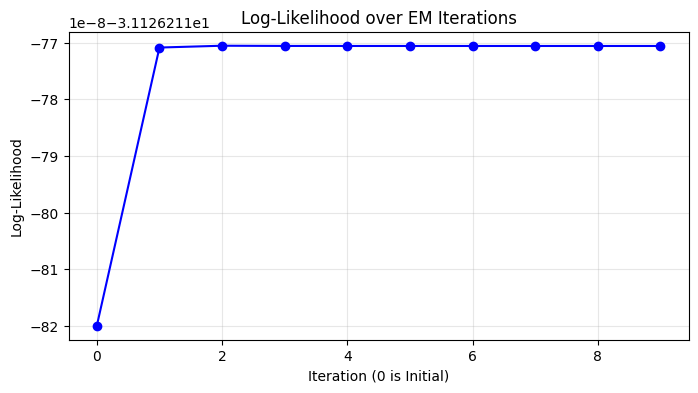

Log-Likelihoods: [np.float64(-31.126211819951166), np.float64(-31.126211770866256), np.float64(-31.1262117705457), np.float64(-31.126211770584298), np.float64(-31.126211770589954), np.float64(-31.126211770590658), np.float64(-31.126211770590697), np.float64(-31.12621177059078), np.float64(-31.1262117705907), np.float64(-31.12621177059074)]


In [46]:
# Plotting
plt.figure(figsize=(8, 4))
plt.plot(range(len(log_likelihoods_2)), log_likelihoods_2, marker='o', linestyle='-', color='b')
plt.title("Log-Likelihood over EM Iterations")
plt.xlabel("Iteration (0 is Initial)")
plt.ylabel("Log-Likelihood")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Log-Likelihoods: {log_likelihoods_2}")

#### Part 4 
Plot the log likelihood of the model given the data after each EM step. Compare the log
likelihood between using two mixtures and three mixtures. Which one has the better likelihood?
(3 points)

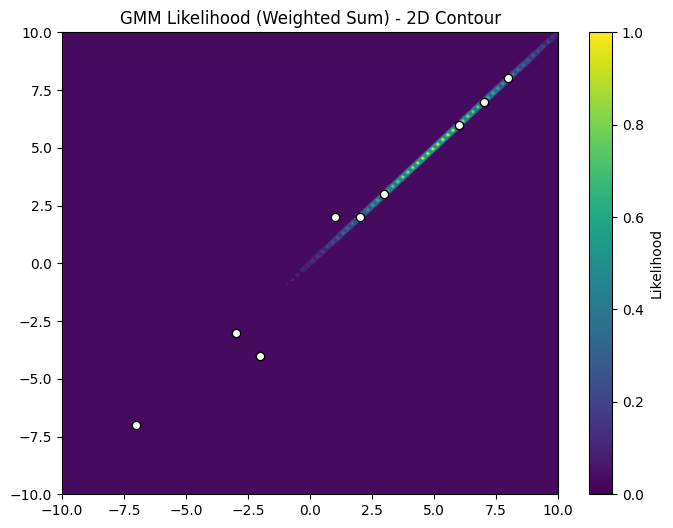

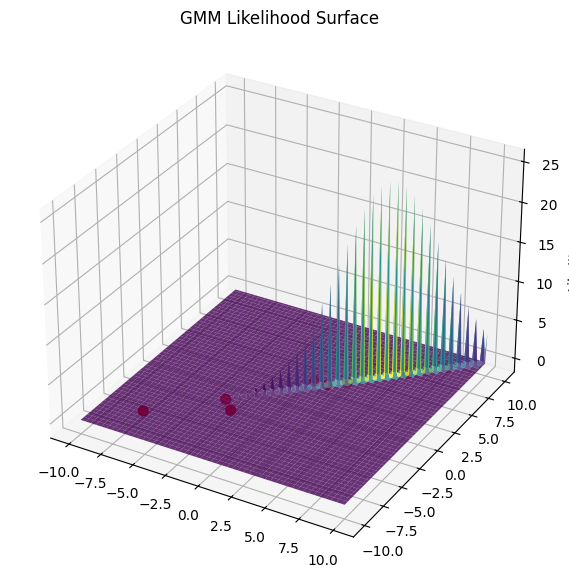

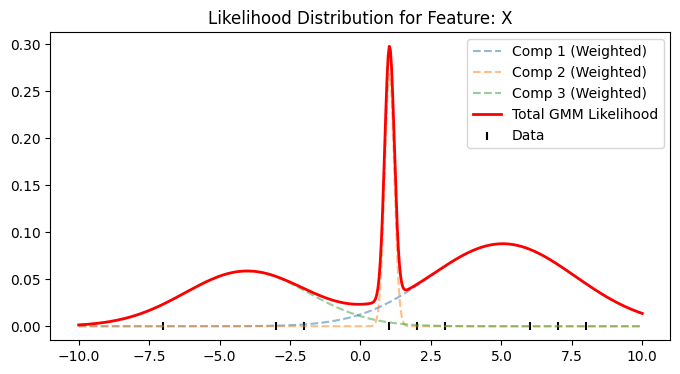

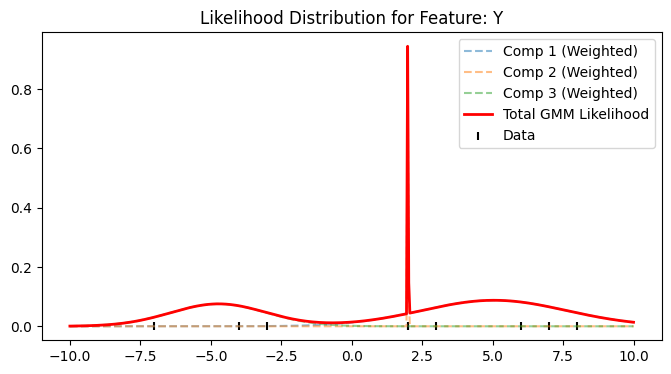

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Create a grid for the plot
x_range = np.linspace(-10, 10, 100)
y_range = np.linspace(-10, 10, 100)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
pos = np.dstack((X_grid, Y_grid))

def plot_marginal(phi, k, mu, sigma, feature_index, label):
    x_line = np.linspace(-10, 10, 500)
    total_pdf = np.zeros_like(x_line)
    
    plt.figure(figsize=(8, 4))
    for j in range(k):
        # Use mean and variance of specific feature
        m = mu[j][feature_index]
        s = np.sqrt(sigma[j][feature_index, feature_index])
        
        # Calculate weighted component
        component_pdf = phi[j] * (1/(s * np.sqrt(2*np.pi)) * np.exp(-0.5*((x_line-m)/s)**2))
        total_pdf += component_pdf
        plt.plot(x_line, component_pdf, '--', alpha=0.5, label=f'Comp {j+1} (Weighted)')

    plt.plot(x_line, total_pdf, 'r-', linewidth=2, label='Total GMM Likelihood')
    plt.scatter(X[:, feature_index], np.zeros(len(X)), c='black', marker='|', label='Data')
    plt.title(f"Likelihood Distribution for Feature: {label}")
    plt.legend()
    plt.show()
    
# Calculate weighted sum of Gaussians
Z = np.zeros(X_grid.shape)
for j in range(k):
    Z += phi[j] * multivariate_normal(mu[j], sigma[j]).pdf(pos)

plt.figure(figsize=(8, 6))
plt.contourf(X_grid, Y_grid, Z, levels=20, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c='white', edgecolors='black', label='Data Points')
plt.title("GMM Likelihood (Weighted Sum) - 2D Contour")
plt.colorbar(label='Likelihood')
plt.show()

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X_grid, Y_grid, Z, cmap='viridis', alpha=0.8)
ax.scatter(X[:, 0], X[:, 1], 0, c='red', s=50, label='Data (at Z=0)')
ax.set_zlabel('Likelihood')
plt.title("GMM Likelihood Surface")
plt.show()

plot_marginal(phi, k, mu, sigma, 0, 'X')
plot_marginal(phi, k, mu, sigma, 1, 'Y')

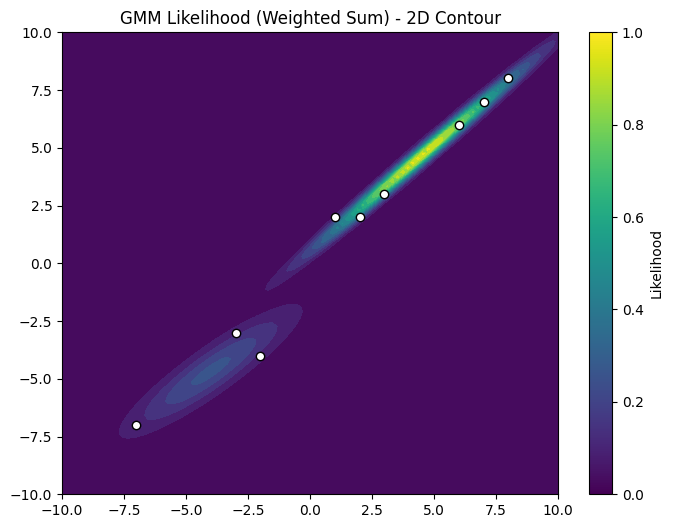

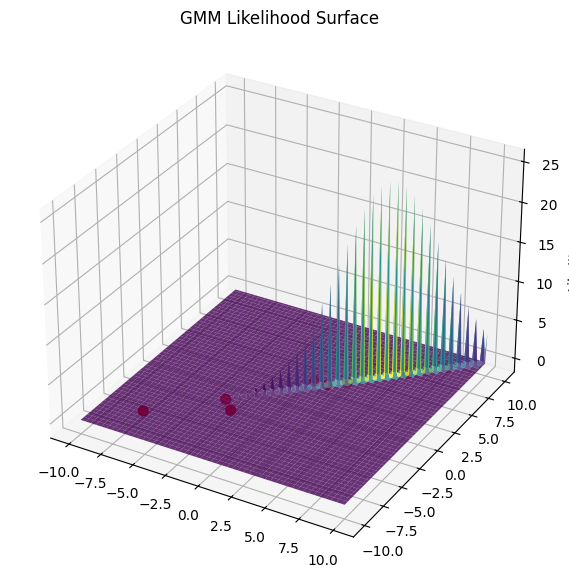

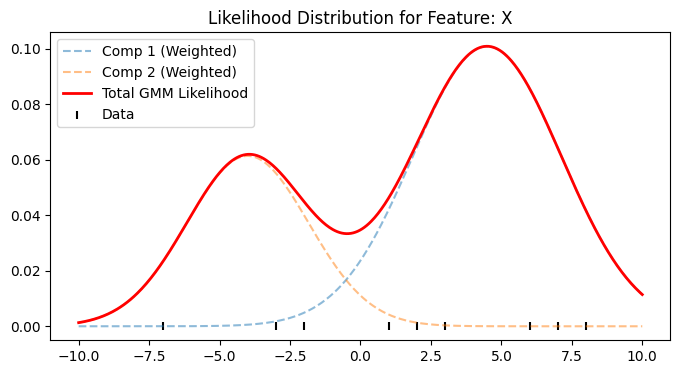

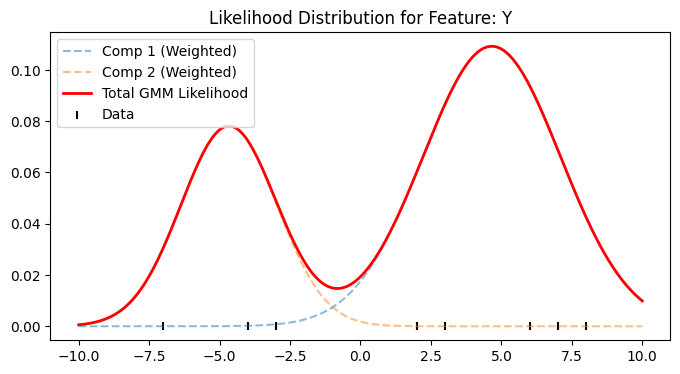

In [44]:
# Calculate weighted sum of Gaussians
Z_2 = np.zeros(X_grid.shape)
for j in range(k_2):
    Z_2 += phi_2[j] * multivariate_normal(mu_2[j], sigma_2[j]).pdf(pos)

plt.figure(figsize=(8, 6))
plt.contourf(X_grid, Y_grid, Z_2, levels=20, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c='white', edgecolors='black', label='Data Points')
plt.title("GMM Likelihood (Weighted Sum) - 2D Contour")
plt.colorbar(label='Likelihood')
plt.show()

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X_grid, Y_grid, Z, cmap='viridis', alpha=0.8)
ax.scatter(X[:, 0], X[:, 1], 0, c='red', s=50, label='Data (at Z=0)')
ax.set_zlabel('Likelihood')
plt.title("GMM Likelihood Surface")
plt.show()

plot_marginal(phi_2, k_2, mu_2, sigma_2, 0, 'X')
plot_marginal(phi_2, k_2, mu_2, sigma_2, 1, 'Y')